In [33]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

## Compare human, egg and avian genotypes at positions of egg adaptation

In [4]:
# read in adaptive muts
adaptive_mut_file = f"../egg-mutation-analysis/egg-adaptive-muts/ha_HA1_adaptive-muts.json"

with open(adaptive_mut_file) as json_handle:
    egg_muts_info = json.load(json_handle)

adaptive_muts_by_virus = {}

for v in ['h3n2', 'h1n1pdm']:
    ha1_adaptive_muts= egg_muts_info['aas_at_adaptive_sites'][v]
    adaptive_muts_by_virus[v] = {int(k):v for k,v in ha1_adaptive_muts.items()}

In [77]:
# observed human and avian genotypes
avian_genotypes = {'h3n2':{138:['A'], 156: ['K'], 160: ['A', 'T'], 
                           183: ['H'], 186: ['S'], 
                                  190: ['E'], 193: ['N', 'S'], 194: ['L'], 195: ['Y'], 196: ['V'],
                                  203: ['T'], 219: ['S'], 225: ['G'], 226: ['Q'], 
                                  246: ['N']}, 
                          'h1n1pdm': {127: ['E'], 187: ['E'], 191: ['L'], 
                                      222: ['G'], 223: ['Q']} }

human_genotypes = {'h3n2':{138:['A'], 156: ['H','Q','S'], 160: ['K', 'T', 'I'], 
                           183: ['H'],186: ['S', 'G', 'D'], 
                                  190: ['D','N'], 193: ['S', 'F'], 194: ['L'], 195: ['Y', 'F'], 196: ['V', 'A'],
                                  203: ['T'], 219: ['S'], 225: ['G', 'D', 'N'], 226: ['V','I'], 
                                  246: ['N']}, 
                          'h1n1pdm': {127: ['D'], 187: ['D'], 191: ['L'], 
                                      222: ['D'], 223: ['Q']} }

In [73]:
def plot_avian_genotype(virus, ax):
    """
    At each egg-adaptive site, give the genotypes observed amongst human viruses and avian viruses 
    as well as the mutations seen in eggs
    """
    
    # column for each adaptive site
    columns = list(adaptive_muts_by_virus[virus].keys())
    rows = ["Human", "Egg", "Avian"] 
    
    human_data = [','.join(human_genotypes[virus][x]) for x in columns]
    egg_data = [','.join(adaptive_muts_by_virus[virus][x]) for x in columns]
    avian_data = [','.join(avian_genotypes[virus][x]) for x in columns]

    
    data = [human_data, egg_data, avian_data] 

    ax.axis("tight")
    ax.axis("off")  # Remove axis

    # Create the table
    table = ax.table(cellText=data, colLabels=columns, rowLabels=rows, loc="center", cellLoc='center')
    
    # Remove borders from header cells
    for (i, j), cell in table.get_celld().items():
        if virus=='h3n2':
            cell.set_text_props(fontsize=18)
            # highlight the avian positions that match an egg-adaptive mut
            if i == 3 and j in [4,8,12]:
                cell.set_facecolor("#a986d5")
        else:
            cell.set_text_props(fontsize=7)
            # highlight the avian positions that match an egg-adaptive mut
            if i == 3 and j in[0,3]:
                cell.set_facecolor("#a2dafe")
        cell.set_height(0.2)
        if i == 0 or j == -1:  
            cell.set_linewidth(0)  
        else:
            cell.set_linewidth(0.5)  
            cell.set_edgecolor('#808080')


    return ax

In [74]:
def plot_avian_supp(filename=None):
    """
    """
    #plot styling
    sns.set_style("white")
    plt.rcParams['figure.dpi']= 300
    plt.rcParams['font.family'] = 'Arial'
    
    prettify_name = {'h3n2': 'A/H3N2', 'h1n1pdm': 'A/H1N1pdm'}
    

    fig = plt.figure(figsize=(8,5))
    gs = GridSpec(2, 5)

    ax1 = fig.add_subplot(gs[0, :])
    plot_avian_genotype('h3n2', ax1)
    ax1.text(-0.03, 0.9, prettify_name['h3n2'], fontsize=12, transform=ax1.transAxes)
    
    ax2 = fig.add_subplot(gs[1, 0:2])
    plot_avian_genotype('h1n1pdm', ax2)
    ax2.text(-0.1, 0.9, prettify_name['h1n1pdm'], fontsize=12, transform=ax2.transAxes)
    
    plt.subplots_adjust(hspace=0.1)
    
    if filename:
        fig.savefig(filename, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')

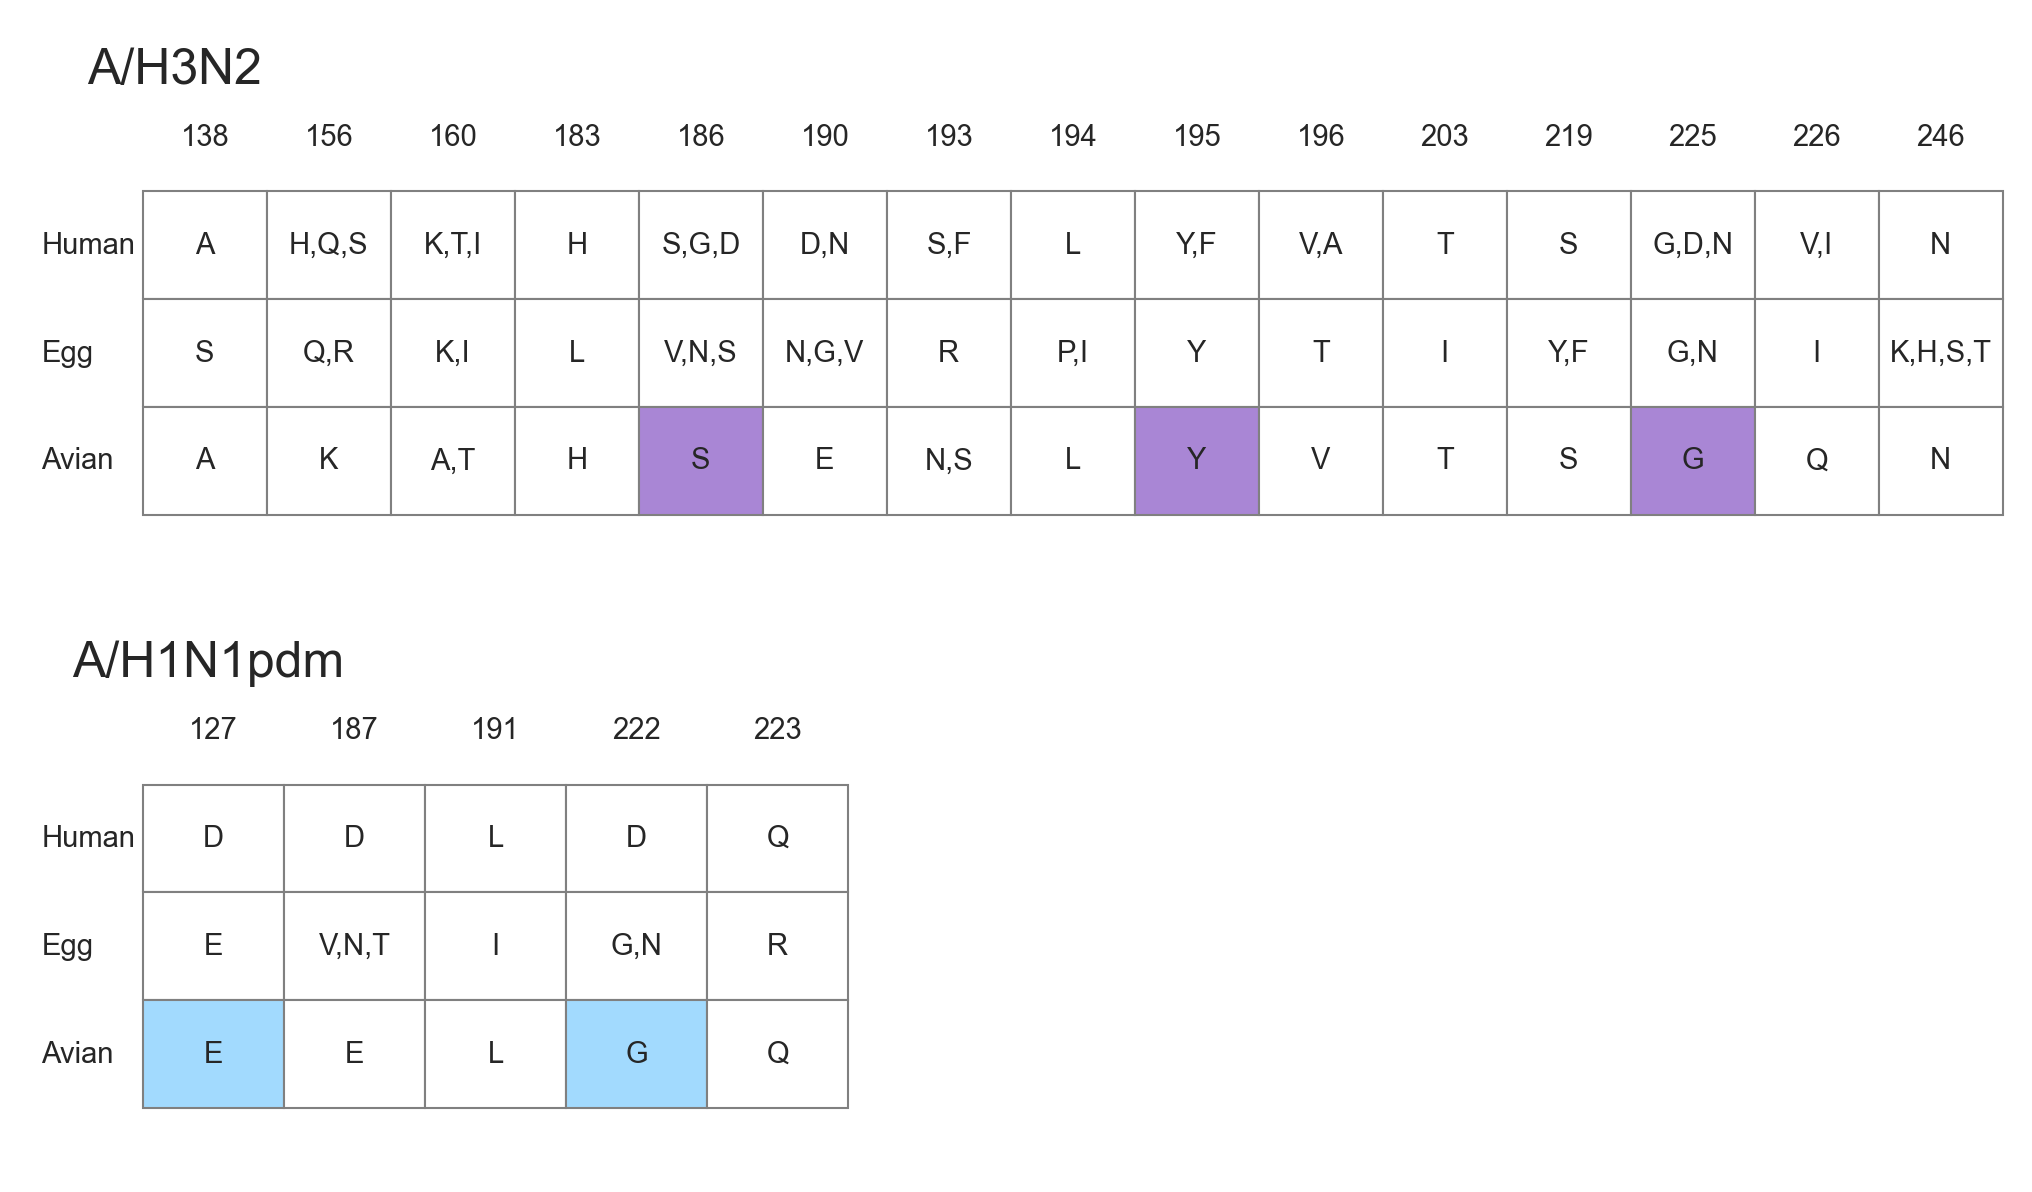

In [76]:
plot_avian_supp(filename='Supplement-AvianGenotypes/Supp_AvianGenotypes.png')